
# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [ ]:
  def Laplace2D(V_ini, x, y, tol=1e-3, max_iter=1000):
    Nmax = V_ini.shape[0]
    V = V_ini.copy()

    for _ in range(int(max_iter)):
      V_prev = V.copy() # Comparación con el valor anterior para evaluar convergencia de la solución
      
      # Iteración 
      for i in range(1, Nmax - 1):
        for j in range(1, Nmax - 1):
          V[i, j] = 0.25 * (V[i + 1, j] + V[i - 1, j] + V[i, j + 1] + V[i, j - 1])

      # Tolerancia
      err = np.max(np.abs(V - V_prev))
      if err < tol:
        break

    X, Y = np.meshgrid(x, y)
    Z = V[X, Y]

    return X, Y, Z


Para esto ya no se define una cantidad de iteraciona hacer, sino que ahora me interesa llegar a valor de tolerancia definida como "tol", 
este valor es lo que yo defno como que tanto acepto el cambio entre el resultado actual y el anterior. en esste caso tomo el cambio mximo en la malla
y cuando este es  menor a "tol" yo considero que "ya convergio" y en esta parte se detiene el codigo.
a veces luego de muchisimas iteraciones no se logra converger, por lo que tambien agrego un numero maximo de iteracion "max_iter" para que no hayan errores y se quede corriendo infinitamente.

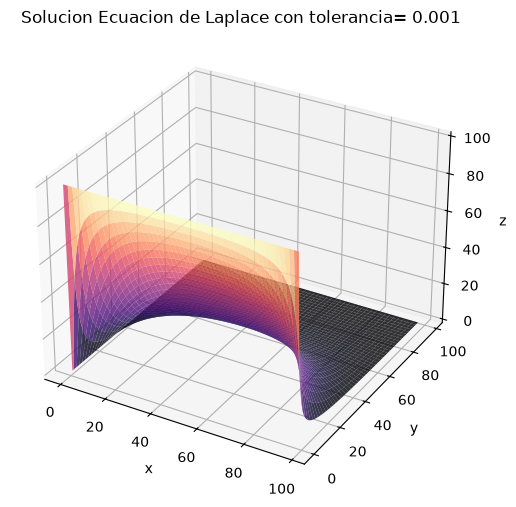

In [ ]:
  Nmax = 100
  tol = 1e-3

  V_ini = np.zeros((Nmax, Nmax), float) 
  for k in range(0, Nmax):
    V_ini[k,0] = 100.0 #La placa de abajo esta a 100V


  x = np.arange(0, Nmax-1, 1)
  y = x

  #Resuelvo la ecuacion de laplace 
  X, Y, Z = Laplace2D(V_ini, x, y)          

  #Grafico
  fig = plt.figure(figsize=(8, 6))
  ax = plt.axes(projection='3d')
  ax.plot_surface(X, Y, Z, cmap='magma', alpha=0.8)
  ax.set_title(f'Solucion Ecuacion de Laplace con tolerancia= {tol}')
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_zlabel('z')
  plt.show()

In [ ]:
Nmax = 100     
L = Nmax - 1   
tol_fdm = 1e-3
tol_fourier = 1e-4

# Solución FDM 
def Laplace2D(V_ini, tol=1e-3, max_iter=20000):
    V = V_ini.copy()
    for it in range(int(max_iter)):
        V_prev = V.copy()
        V[1:-1, 1:-1] = 0.25 * (V_prev[2:, 1:-1] + V_prev[:-2, 1:-1] +
                                 V_prev[1:-1, 2:] + V_prev[1:-1, :-2])
        err = np.max(np.abs(V - V_prev))
        if err < tol:
            break
    return V, it, err

V_ini = np.zeros((Nmax, Nmax))
V_ini[:, 0] = V0  

V_fdm, iteraciones, err_final = Laplace2D(V_ini, tol=tol_fdm)
print(f"FDM: convergió en {iteraciones} iteraciones, error final = {err_final:.2e}")

x = np.arange(Nmax)
y = np.arange(Nmax)
X, Y = np.meshgrid(x, y, indexing='ij')

# -serie de fourier
def sinh_ratio(a, b):
    """Calcula sinh(a)/sinh(b) de forma numéricamente estable (0<=a<=b)."""
    return (np.exp(a - b) - np.exp(-a - b)) / (1.0 - np.exp(-2*b))

def fourier_term(n, X, Y, V0, L):
    a = n*np.pi*(L - Y)/L
    b = n*np.pi
    return (4*V0/(n*np.pi)) * np.sin(n*np.pi*X/L) * sinh_ratio(a, b)

# terminos
N_max_terms = 500
U = np.zeros_like(X, dtype=float)
errores = []
n_terms_necesarios = None

for k in range(N_max_terms):
    n = 2*k + 1  
    nuevo_termino = fourier_term(n, X, Y, V0, L)
    U_nuevo = U + nuevo_termino
    diff = np.max(np.abs(U_nuevo - U))
    errores.append(diff)
    U = U_nuevo
    if diff < tol_fourier and k > 0:
        n_terms_necesarios = k + 1 
        break

if n_terms_necesarios is None:
    n_terms_necesarios = N_max_terms
    print("No se alcanzó la tolerancia en el máximo de términos probado.")
else:
    print(f"Se necesitaron {n_terms_necesarios} términos "
          f"(hasta n={2*n_terms_necesarios-1}) para alcanzar tol = {tol_fourier}")

U_fourier = U

#comparacion
error_fdm_fourier = np.max(np.abs(V_fdm - U_fourier))
print(f"Diferencia máxima entre FDM y serie de Fourier: {error_fdm_fourier:.4f} V")

FDM: convergió en 5990 iteraciones, error final = 1.00e-03
Se necesitaron 50 términos (hasta n=99) para alcanzar tol = 0.0001
Diferencia máxima entre FDM y serie de Fourier: 100.0000 V




#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** 

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

In [4]:
#Ecuacion de Laplace para el capacitor
def Laplace2DCapacitor(V_ini, x, y, fixed, tol=1e-3, max_iter=1000):

    Nmax = V_ini.shape[0]
    V = V_ini.copy()

    for _ in range(int(max_iter)):

        # Valor anterior para evaluar convergencia
        V_prev = V.copy()

        # Iteración sobre el grid
        for i in range(1, Nmax - 1):
            for j in range(1, Nmax - 1):

                # No modificar los puntos que pertenecen a las placas
                if not fixed[i, j]:

                    V[i, j] = 0.25 * (
                        V[i + 1, j] +
                        V[i - 1, j] +
                        V[i, j + 1] +
                        V[i, j - 1]
                    )

        # Tolerancia
        err = np.max(np.abs(V - V_prev))

        if err < tol:
            print("Convergence reached")
            print("Iterations:", _)
            print("Error:", err)
            break

    # Grid
    X, Y = np.meshgrid(x, y)

    return X, Y, V

Convergence reached
Iterations: 955
Error: 0.000999420857221267


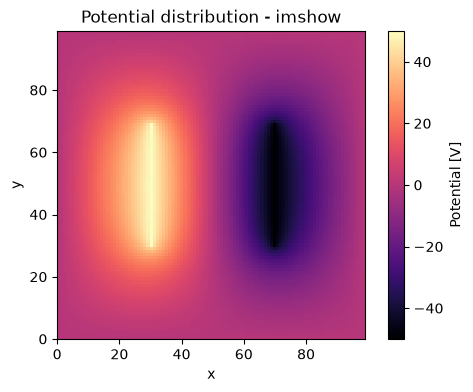

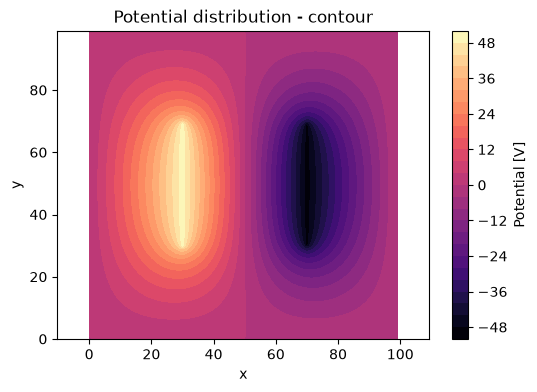

In [5]:
Nmax = 100
tol = 1e-3

V_ini = np.zeros((Nmax, Nmax), float)

x = np.arange(Nmax)
y = np.arange(Nmax)

#Coordenadas de las placas
V_ini[30:70, 30] = 50.0 #Positiva
#fixed[30:70, 30] = True

V_ini[30:70, 70] = -50.0 #Negativa
#fixed[30:70, 70] = True

#puntos fijos
fixed = np.zeros((Nmax, Nmax), dtype=bool)
fixed[30:70, 30] = True #positiva
fixed[30:70, 70] = True #negativa

#Solucion de Laplace y graficos
X, Y, Z = Laplace2DCapacitor(
    V_ini,
    x,
    y,
    fixed,
    tol=tol,
    max_iter=10000
)


plt.figure(figsize=(6, 4)) #grafico con imshow
plt.imshow( 
    Z,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin='lower',
    aspect='equal',
    cmap ='magma'
)
plt.colorbar(label='Potential [V]')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Potential distribution - imshow")
plt.show()


plt.figure(figsize=(6, 4)) #grafco con contourf
contour = plt.contourf(
    X,
    Y,
    Z,
    levels=30,
     cmap ='magma'
)
plt.colorbar(contour, label='Potential [V]')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Potential distribution - contour")
plt.axis('equal')
plt.show()

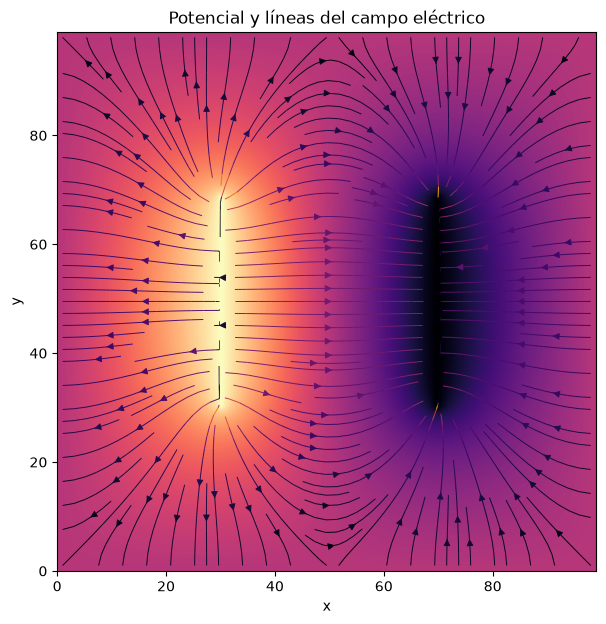

|E| máximo = 7.498 V/unidad


In [ ]:
# Campo eléctrico usando diferencias finitas
Delta_cap = 1.0
U = Z.copy()


Ey = -(U[2:, 1:-1] - U[:-2, 1:-1]) / (2 * Delta_cap)   
Ex = -(U[1:-1, 2:] - U[1:-1, :-2]) / (2 * Delta_cap)  

#coordenadas
xE = np.arange(1, Nmax - 1) * Delta_cap
yE = np.arange(1, Nmax - 1) * Delta_cap
XE, YE = np.meshgrid(xE, yE) 

magnitude = np.sqrt(Ex**2 + Ey**2)


#Grafico
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(
    U,
    origin='lower',
    cmap='magma',
    extent=[x.min(), x.max(), y.min(), y.max()],
    interpolation='bilinear',
    aspect='equal'
)

# Líneas de campo
ax.streamplot(
    XE, YE,
    Ex, Ey,
    color=magnitude,
    cmap='inferno',
    density=1.5,
    linewidth=0.7
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Potencial y líneas del campo eléctrico')
plt.show()

print(f"|E| máximo = {np.max(magnitude):.3f} V/unidad")